In [1]:
#Ensure you have installed the required libraries, including pandas, matplotlib, and opencv-python for image handling.
!pip install pandas matplotlib opencv-python
!pip install tensorflow




In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2



In [3]:
#Load the classes_rgb_values.csv and video_info.csv files to inspect the data distribution and class information.

# Define paths to the metadata files
classes_rgb_values_path = r"D:\proiectSBC\archive 1\classes_rgb_values.csv"
video_info_path = r"D:\proiectSBC\archive 1\video_info.csv"

# Load CSV files into DataFrames
class_rgb_values = pd.read_csv(classes_rgb_values_path)
video_info = pd.read_csv(video_info_path)

# Display the first few rows of each to understand their structure
display(class_rgb_values.head())
display(video_info.head())



,index,semantic_class,rgb_values,relative_percentile_frequency
0,0,Traffic Sign,"[220,2200]",0.05
1,1,Building,"[70,70,70]",14.08
2,2,Fence,"[190,153,153]",0.28
3,3,Other,"[250,170,160]",0.29
4,4,Pedestrian,"[220,20,60]",1.02


,Index,duration_seconds,weather,driving_scenario,n_images
0,0,30.4,Sunny,Driving,305
1,1,34.1,Sunny,Driving + Traffic am,342
2,2,36.2,Sunny,Driving,363
3,3,35.0,Sunny,Driving + Traffic am,350
4,4,33.4,Sunny,Driving,335


Index(['Index', 'duration_seconds', 'weather', 'driving_scenario', 'n_images'], dtype='object')


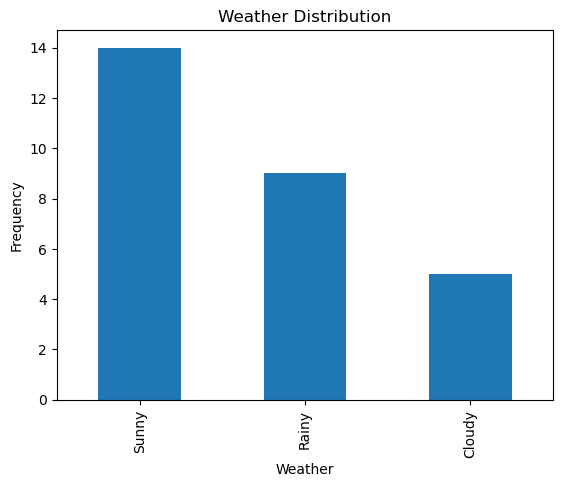

In [4]:
# Use video_info.csv to analyze details such as the weather distribution and the duration of each video sequence.

# Check column names and ensure 'weather' and 'duration' columns exist
print(video_info.columns)

# Weather distribution
weather_distribution = video_info['weather'].value_counts()
weather_distribution.plot(kind='bar', title='Weather Distribution')
plt.xlabel('Weather')
plt.ylabel('Frequency')
plt.show()



In [5]:
print(video_info.columns)


Index(['Index', 'duration_seconds', 'weather', 'driving_scenario', 'n_images'], dtype='object')


In [6]:
display(video_info.head())


,Index,duration_seconds,weather,driving_scenario,n_images
0,0,30.4,Sunny,Driving,305
1,1,34.1,Sunny,Driving + Traffic am,342
2,2,36.2,Sunny,Driving,363
3,3,35.0,Sunny,Driving + Traffic am,350
4,4,33.4,Sunny,Driving,335


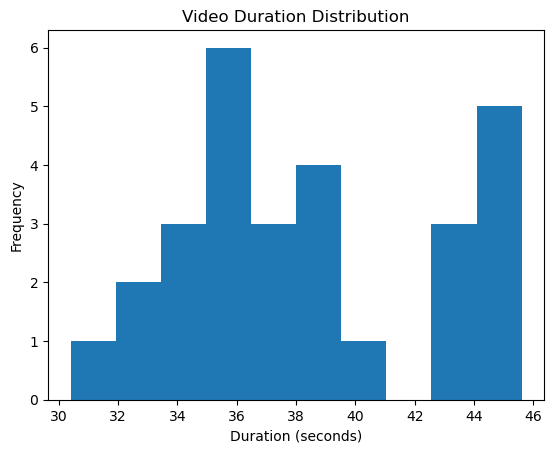

In [7]:
# Video duration distribution
video_info['duration_seconds'].plot(kind='hist', title='Video Duration Distribution')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

In [8]:
print(class_rgb_values.columns)

Index(['index', 'semantic_class', 'rgb_values',
       'relative_percentile_frequency'],
      dtype='object')


In [9]:
display(class_rgb_values.head())


,index,semantic_class,rgb_values,relative_percentile_frequency
0,0,Traffic Sign,"[220,2200]",0.05
1,1,Building,"[70,70,70]",14.08
2,2,Fence,"[190,153,153]",0.28
3,3,Other,"[250,170,160]",0.29
4,4,Pedestrian,"[220,20,60]",1.02


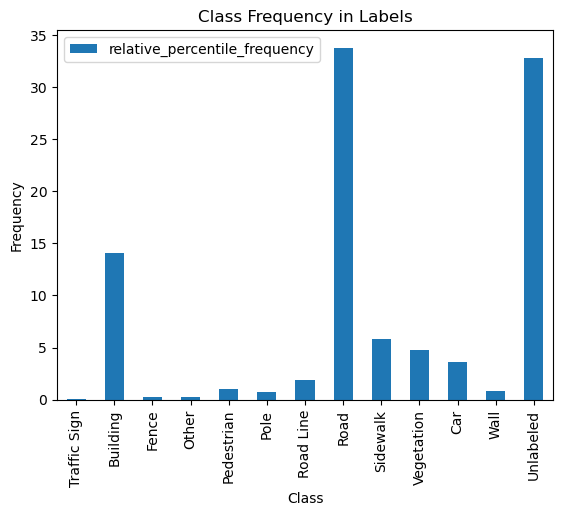

In [10]:
#This file provides RGB values for each semantic class. Use it to explore the frequency of different semantic classes.

# Class Frequency Distribution
class_rgb_values.plot(kind='bar', x='semantic_class', y='relative_percentile_frequency', title='Class Frequency in Labels')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

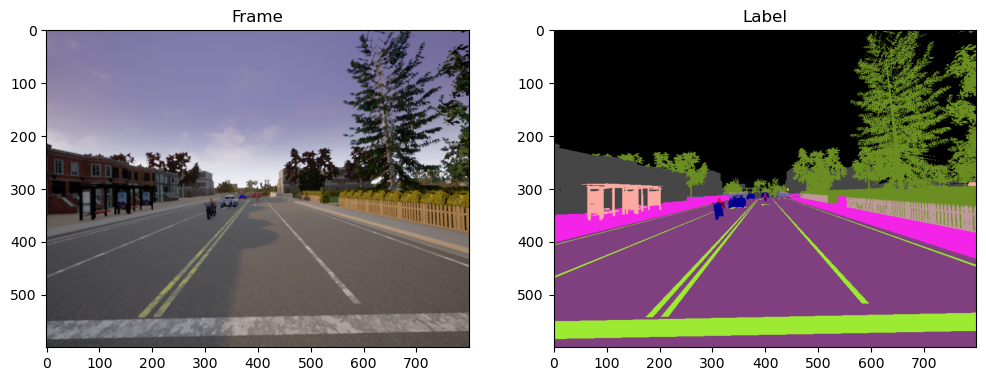

In [11]:
#To visually inspect the dataset, load a few sample frames and their corresponding semantic labels. Adjust the paths to the images and labels folders.


# Define paths to images and labels directories
images_dir = r"D:\proiectSBC\archive 1\images"
labels_dir = r"D:\proiectSBC\archive 1\labels"

# Load and display a sample image and its corresponding label
sample_image_path = os.path.join(images_dir, "Video_000", "v000_0000.png")  # Adjust filename as needed
sample_label_path = os.path.join(labels_dir, "Video_000", "v000_0000.png")  # Corresponding label file

# Load and display the image
image = cv2.imread(sample_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Load and display the label
label = cv2.imread(sample_label_path)
label = cv2.cvtColor(label, cv2.COLOR_BGR2RGB)

# Display side-by-side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Frame')

plt.subplot(1, 2, 2)
plt.imshow(label)
plt.title('Label')
plt.show()


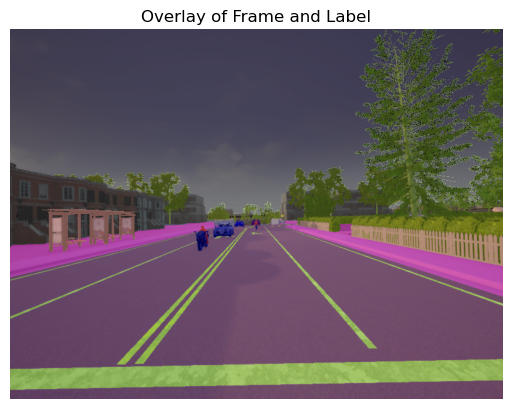

In [12]:
# To get a better sense of the labeled data, overlay the labels on the original frames using transparency.

alpha = 0.5  # Transparency factor
overlay = cv2.addWeighted(image, alpha, label, 1 - alpha, 0)

# Display the overlay
plt.imshow(overlay)
plt.title('Overlay of Frame and Label')
plt.axis('off')
plt.show()


In [13]:
# If class_rgb_values.csv contains RGB values for each semantic class, you can use these values to colorize the bars in a class frequency plot.
# Assuming 'class_name', 'frequency', and 'R', 'G', 'B' columns in class_rgb_values

# Create a custom color mapping for each class based on RGB values
print(class_rgb_values.columns)


Index(['index', 'semantic_class', 'rgb_values',
       'relative_percentile_frequency'],
      dtype='object')


In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils import shuffle
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# --- 1. CONFIGURARE ---
BASE_PATH = r"D:\proiectSBC\archive 1"
IMG_WIDTH, IMG_HEIGHT = 256, 256  
BATCH_SIZE = 4    # Am scăzut la 4 pentru că modelul e mult mai "greu" acum (evităm OOM)
EPOCHS = 100      
LIMIT_TOTAL = 1500 
IMGS_PER_VIDEO = 40 

MODEL_FINAL = 'model_heavy_256px_cruise.keras'

# --- 2. PREGĂTIRE CULORI ---
classes_file = os.path.join(BASE_PATH, "classes_rgb_values.csv")
df_classes = pd.read_csv(classes_file)

def get_clean_colors(val):
    s = str(val).replace('[', '').replace(']', '').replace('"', '').replace("'", "")
    parts = [int(p.strip()) for p in s.split(',') if p.strip().isdigit()]
    if len(parts) >= 2 and parts[1] == 2200: parts[1] = 220
    while len(parts) < 3: parts.append(0)
    return parts[:3]

class_colors = np.array([get_clean_colors(x) for x in df_classes['rgb_values']], dtype=np.int32)
num_classes = len(class_colors)

# --- 3. FUNCȚIE ÎNCĂRCARE DATE (DIVERSIFICATĂ) ---
def load_data_final(total_limit=1000, imgs_per_dir=40):
    images, masks = [], []
    img_dir = os.path.join(BASE_PATH, "images")
    all_pairs = []
    
    for root, dirs, files in os.walk(img_dir):
        png_files = [f for f in files if f.endswith(".png")]
        if not png_files: continue
        
        video_files = sorted(png_files)[:imgs_per_dir]
        for file in video_files:
            img_path = os.path.join(root, file)
            mask_path = img_path.replace("images", "labels")
            if os.path.exists(mask_path):
                all_pairs.append((img_path, mask_path))

    all_pairs = shuffle(all_pairs, random_state=42)
    all_pairs = all_pairs[:total_limit]

    print(f"Încărcăm {len(all_pairs)} imagini în noul creier...")
    for i, (img_p, mask_p) in enumerate(all_pairs):
        img = cv2.imread(img_p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        images.append(img / 255.0)
        
        m_rgb = cv2.imread(mask_p)
        m_rgb = cv2.cvtColor(m_rgb, cv2.COLOR_BGR2RGB)
        m_rgb = cv2.resize(m_rgb, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
        
        label_mask = np.zeros((IMG_HEIGHT, IMG_WIDTH), dtype=np.uint8)
        for idx, color in enumerate(class_colors):
            match = np.all(m_rgb == color, axis=-1)
            label_mask[match] = idx
        masks.append(label_mask)
            
    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.uint8)

X, Y = load_data_final(total_limit=LIMIT_TOTAL, imgs_per_dir=IMGS_PER_VIDEO)
Y_final = np.expand_dims(Y, axis=-1)

# --- 4. ARHITECTURĂ U-NET ---
def build_model_heavy():
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, 3))
    
    # Encoder
    c1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)
    
    c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)
    
    # Bottleneck - Puterea maximă de procesare
    c3 = Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(c3)
    c3 = Dropout(0.4)(c3) 
    
    # Decoder
    u4 = Conv2DTranspose(128, 2, strides=2, padding='same')(c3)
    u4 = concatenate([u4, c2])
    c4 = Conv2D(128, 3, activation='relu', padding='same')(u4)
    c4 = BatchNormalization()(c4)
    
    u5 = Conv2DTranspose(64, 2, strides=2, padding='same')(c4)
    u5 = concatenate([u5, c1])
    c5 = Conv2D(64, 3, activation='relu', padding='same')(u5)
    c5 = BatchNormalization()(c5)
    
    outputs = Conv2D(num_classes, 1, activation='softmax')(c5)
    return Model(inputs, outputs)

# --- 5. COMPILARE ---
model = build_model_heavy()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# --- 6. CALLBACKS ---
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
checkpoint = ModelCheckpoint(MODEL_FINAL, monitor='val_accuracy', save_best_only=True, verbose=1)

# --- 7. ANTRENAMENT (DE LA 0) ---
print("\n--- PORNEȘTE ANTRENAMENTUL HEAVY (AȘTEAPTĂ REZULTATELE) ---")
history = model.fit(X, Y_final, 
                    batch_size=BATCH_SIZE, 
                    epochs=EPOCHS, 
                    validation_split=0.15, 
                    shuffle=True, 
                    callbacks=[checkpoint, early_stop, reduce_lr],
                    verbose=1)

# --- 8. VIZUALIZARE REZULTAT PROFI ---
idx = np.random.randint(0, len(X))
pred = model.predict(X[idx:idx+1])
pred_mask = np.argmax(pred[0], axis=-1)
# Netezire pentru demo
cleaned_mask = cv2.medianBlur(pred_mask.astype(np.uint8), 5)

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1); plt.imshow(X[idx]); plt.title("Imagine Intrare")
plt.subplot(1,3,2); plt.imshow(cleaned_mask, cmap='nipy_spectral'); plt.title("Predicție HEAVY (Curățată)")
plt.subplot(1,3,3); plt.imshow(Y[idx], cmap='nipy_spectral'); plt.title("Label Real")
plt.show()

Încărcăm 1120 imagini în noul creier...

--- PORNEȘTE ANTRENAMENTUL HEAVY (AȘTEAPTĂ REZULTATELE) ---
Epoch 1/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6311 - loss: 1.3400   
Epoch 1: val_accuracy improved from None to 0.46421, saving model to model_heavy_256px_cruise.keras

Epoch 1: finished saving model to model_heavy_256px_cruise.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 625s 3s/step - accuracy: 0.7539 - loss: 0.8850 - val_accuracy: 0.4642 - val_loss: 1.8657 - learning_rate: 1.0000e-04
Epoch 2/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8742 - loss: 0.4277  
Epoch 2: val_accuracy improved from 0.46421 to 0.68187, saving model to model_heavy_256px_cruise.keras

Epoch 2: finished saving model to model_heavy_256px_cruise.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 588s 2s/step - accuracy: 0.8861 - loss: 0.3886 - val_accuracy: 0.6819 - val_loss: 1.1951 - learning_rate: 1.0000e-04
Epoch 3/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9184 - loss: 0.2797  
Epoch 3

KeyboardInterrupt: 

In [11]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
import numpy as np

# --- 1. CONFIGURARE ---
MODEL_DE_INCARCAT = 'model_heavy_FINAL_cars.keras'
ID_VEHICUL = 10 
NOUL_MODEL_SAVE = 'model_heavy_FINAL_cars2.keras'

# --- 2. ÎNCĂRCARE MODEL ---
print(f"Se încarcă modelul: {MODEL_DE_INCARCAT}")
model = load_model(MODEL_DE_INCARCAT)

# --- 3. CREARE SAMPLE WEIGHTS (Soluția pentru segmentare) ---
# În segmentare, class_weight nu merge. Trebuie să facem o matrice de greutăți
# de aceeași formă cu Y_final, unde pixelii de mașină au valoare mare (25).
# --- GENERARE WEIGHTS MAP FINALĂ (Echilibrată) ---
print("Generăm harta de greutăți: Focus pe Mașini + Curățare Clădiri...")

# 1. Baza (1.0) pentru Cer, Unlabeled, Vegetation
weights_map = np.ones_like(Y_final, dtype=np.float32)

# 2. PRIORITATE ZERO: Mașinile (Index 10) -> "Biciul" x25
weights_map[Y_final == 10] = 25.0

# 3. SIGURANȚĂ: Pedestrians (Index 4) -> x15 (Să nu-i confundăm cu mașini)
weights_map[Y_final == 4] = 15.0

# 4. STRUCTURĂ: Fence (Index 2) și Wall (Index 11) -> x10
weights_map[Y_final == 2] = 10.0
weights_map[Y_final == 11] = 10.0

# 5. CURĂȚARE: Building (Index 1) -> x3.0
# Îi dăm o pondere moderată să nu mai facă "Tetris"
weights_map[Y_final == 1] = 3.0

# 6. ASISTENȚĂ: Road (Index 7) -> x2.0
# Menținem asfaltul stabil
weights_map[Y_final == 7] = 2.0
# --- 4. RE-COMPILARE ---
model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5. START FINE-TUNING ---
print("\n--- PORNEȘTE RE-EDUCAREA: PRIORITATE MAXIMĂ PE VEHICULE ---")
history_fine = model.fit(
    X, Y_final, 
    batch_size=BATCH_SIZE, 
    epochs=10, 
    validation_split=0.15, 
    shuffle=True,
    sample_weight=weights_map, # <--- AM SCHIMBAT din class_weight în sample_weight
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(NOUL_MODEL_SAVE, monitor='val_accuracy', save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ],
    verbose=1
)

Se încarcă modelul: model_heavy_FINAL_cars.keras
Generăm harta de greutăți: Focus pe Mașini + Curățare Clădiri...

--- PORNEȘTE RE-EDUCAREA: PRIORITATE MAXIMĂ PE VEHICULE ---
Epoch 1/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9646 - loss: 0.3561  
Epoch 1: val_accuracy improved from None to 0.96518, saving model to model_heavy_FINAL_cars2.keras

Epoch 1: finished saving model to model_heavy_FINAL_cars2.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 588s 2s/step - accuracy: 0.9644 - loss: 0.3244 - val_accuracy: 0.9652 - val_loss: 0.2909
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9640 - loss: 0.3122  
Epoch 2: val_accuracy did not improve from 0.96518
238/238 ━━━━━━━━━━━━━━━━━━━━ 566s 2s/step - accuracy: 0.9638 - loss: 0.3059 - val_accuracy: 0.9641 - val_loss: 0.2847
Epoch 3/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9630 - loss: 0.2965  
Epoch 3: val_accuracy did not improve from 0.96518
238/238 ━━━━━━━━━━━━━━━━━━━━ 583s 2s/step - accuracy: 0.9631 -

KeyboardInterrupt: 

In [12]:
model.save('model_heavy_FINAL_REPARAT.keras')
print("Salvare manuală reușită!")


Salvare manuală reușită!


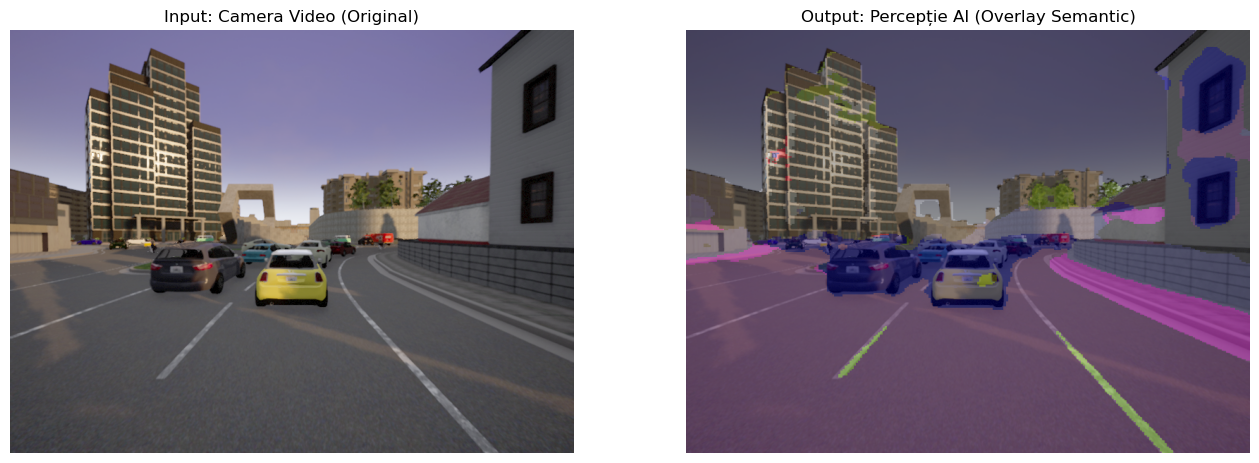

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from IPython.display import clear_output, display

# --- 1. CONFIGURARE ---
MODEL_PATH = 'model_heavy_FINAL_REPARAT.keras'
IMG_DIR = r"D:\proiectSBC\archive 1\images\Video_001"
W, H = 256, 256

# --- 2. PALETA DE CULORI (RGB) ---
PALETA_CULORI = {
    0:  [220, 220, 0],   1:  [70, 70, 70],    2:  [190, 153, 153], 
    3:  [250, 170, 160], 4:  [220, 20, 60],   5:  [153, 153, 153], 
    6:  [157, 234, 50],  7:  [128, 64, 128],  8:  [244, 35, 232],  
    9:  [107, 142, 35],  10: [0, 0, 142],     11: [102, 102, 156], 
    12: [0, 0, 0]
}

# --- 3. INCARCARE MODEL ---
model = load_model(MODEL_PATH)
fisiere = sorted([f for f in os.listdir(IMG_DIR) if f.endswith(".png")])

# Creăm o figură cu 2 subplot-uri (1 rând, 2 coloane)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

try:
    for nume in fisiere[:150]:
        frame = cv2.imread(os.path.join(IMG_DIR, nume))
        if frame is None: continue
        
        # Sursă originală pentru afișare
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Pregătire pentru model
        img_in = cv2.resize(frame_rgb, (W, H)) / 255.0
        pred = model.predict(np.expand_dims(img_in, axis=0), verbose=0)
        mask = np.argmax(pred[0], axis=-1).astype(np.uint8)
        mask = cv2.medianBlur(mask, 5)

        # Creare mască colorată
        vis_mask = np.zeros((H, W, 3), dtype=np.uint8)
        for idx, rgb in PALETA_CULORI.items():
            vis_mask[mask == idx] = rgb
        
        # Overlay pe imaginea originală
        vis_mask_res = cv2.resize(vis_mask, (frame.shape[1], frame.shape[0]), interpolation=cv2.INTER_NEAREST)
        overlay = cv2.addWeighted(frame_rgb, 0.6, vis_mask_res, 0.4, 0)

        # --- ACTUALIZARE VIZUALĂ SIDE-BY-SIDE ---
        ax1.clear()
        ax1.imshow(frame_rgb)
        ax1.set_title("Input: Camera Video (Original)")
        ax1.axis('off')
        
        ax2.clear()
        ax2.imshow(overlay)
        ax2.set_title("Output: Percepție AI (Overlay Semantic)")
        ax2.axis('off')
        
        clear_output(wait=True)
        display(fig)
        
except KeyboardInterrupt:
    print("Redare oprită.")

plt.close()

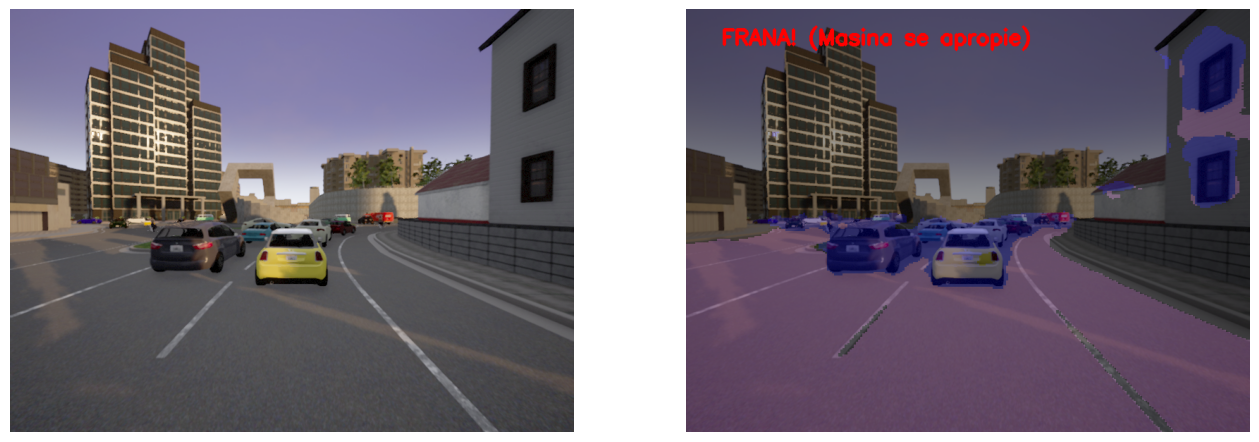

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from IPython.display import clear_output, display

# --- CONFIGURARE ---
MODEL_PATH = 'model_heavy_FINAL_REPARAT.keras'
IMG_DIR = r"D:\proiectSBC\archive 1\images\Video_001"
W, H = 256, 256
ID_CAR = 10 # Clasa pentru masini

model = load_model(MODEL_PATH)
fisiere = sorted([f for f in os.listdir(IMG_DIR) if f.endswith(".png")])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

prev_car_pixels = 0 # Memorie pentru cadrul anterior
threshold = 50      # Sensibilitate (sa nu oscileze la 1-2 pixeli diferenta)

try:
    for nume in fisiere[:150]:
        frame = cv2.imread(os.path.join(IMG_DIR, nume))
        if frame is None: continue
        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_in = cv2.resize(frame_rgb, (W, H)) / 255.0
        pred = model.predict(np.expand_dims(img_in, axis=0), verbose=0)
        mask = np.argmax(pred[0], axis=-1).astype(np.uint8)
        mask = cv2.medianBlur(mask, 5)

        # --- LOGICA DE CONTROL (FRANA / ACCELERARE) ---
        # Numaram pixelii de tip "Car" in masca curenta
        current_car_pixels = np.sum(mask == ID_CAR)
        
        comanda = "MENTINERE VITEZA"
        culoare_text = (255, 255, 255) # Alb

        if prev_car_pixels > 0: # Sarim peste primul cadru
            diff = current_car_pixels - prev_car_pixels
            
            if diff > threshold:
                comanda = "FRANA! (Masina se apropie)"
                culoare_text = (255, 0, 0) # Rosu
            elif diff < -threshold:
                comanda = "ACCELERARE (Drum liber)"
                culoare_text = (0, 255, 0) # Verde

        prev_car_pixels = current_car_pixels # Salvam pentru cadrul urmator

        # --- VIZUALIZARE ---
        vis_mask = np.zeros((H, W, 3), dtype=np.uint8)
        # (Aici ramane paleta ta de culori - am scurtat pentru exemplu)
        vis_mask[mask == ID_CAR] = [0, 0, 142] 
        vis_mask[mask == 7] = [128, 64, 128] # Road
        
        vis_mask_res = cv2.resize(vis_mask, (frame.shape[1], frame.shape[0]), interpolation=cv2.INTER_NEAREST)
        overlay = cv2.addWeighted(frame_rgb, 0.6, vis_mask_res, 0.4, 0)

        # Adaugam textul comenzii pe imaginea Overlay
        cv2.putText(overlay, comanda, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, culoare_text, 3)

        ax1.clear(); ax1.imshow(frame_rgb); ax1.axis('off')
        ax2.clear(); ax2.imshow(overlay); ax2.axis('off')
        
        clear_output(wait=True)
        display(fig)
        
except KeyboardInterrupt:
    print("Redare oprită.")
plt.close()